In [1]:
# Exploratory Data Analysis

In [ ]:
#  Import required libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("processed_data/cleaned_data.csv")

In [3]:
df.head()

,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diabetesMed,A1Cresult_numeric,metformin_numeric,glipizide_numeric,glyburide_numeric,insulin_numeric,readmit_high_risk,admission_type_name,total_visits,med_adj_count
0,Caucasian,Female,0-10,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,Other/Unknown,0,0
1,Caucasian,Female,10-20,3,59,0,18,0,0,0,...,1,0,0,0,0,2,0,Emergency,0,1
2,AfricanAmerican,Female,20-30,2,11,5,13,2,0,1,...,1,0,0,1,0,0,0,Emergency,3,0
3,Caucasian,Male,30-40,2,44,1,16,0,0,0,...,1,0,0,0,0,2,0,Emergency,0,1
4,Caucasian,Male,40-50,1,51,0,8,0,0,0,...,1,0,0,1,0,1,0,Emergency,0,0


In [4]:
df.columns

Index(['race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'A1Cresult', 'metformin', 'glipizide', 'glyburide',
       'insulin', 'change', 'diabetesMed', 'A1Cresult_numeric',
       'metformin_numeric', 'glipizide_numeric', 'glyburide_numeric',
       'insulin_numeric', 'readmit_high_risk', 'admission_type_name',
       'total_visits', 'med_adj_count'],
      dtype='object')

# 1. Demographic vs Clinical behavior

--- Percentage of Patients Entering via Emergency Room ---
race
AfricanAmerican    64.494993
Caucasian          50.214228
Hispanic           49.876054
Unknown            46.600108
Asian              41.719745
Name: Emergency, dtype: float64


<Figure size 1200x600 with 0 Axes>

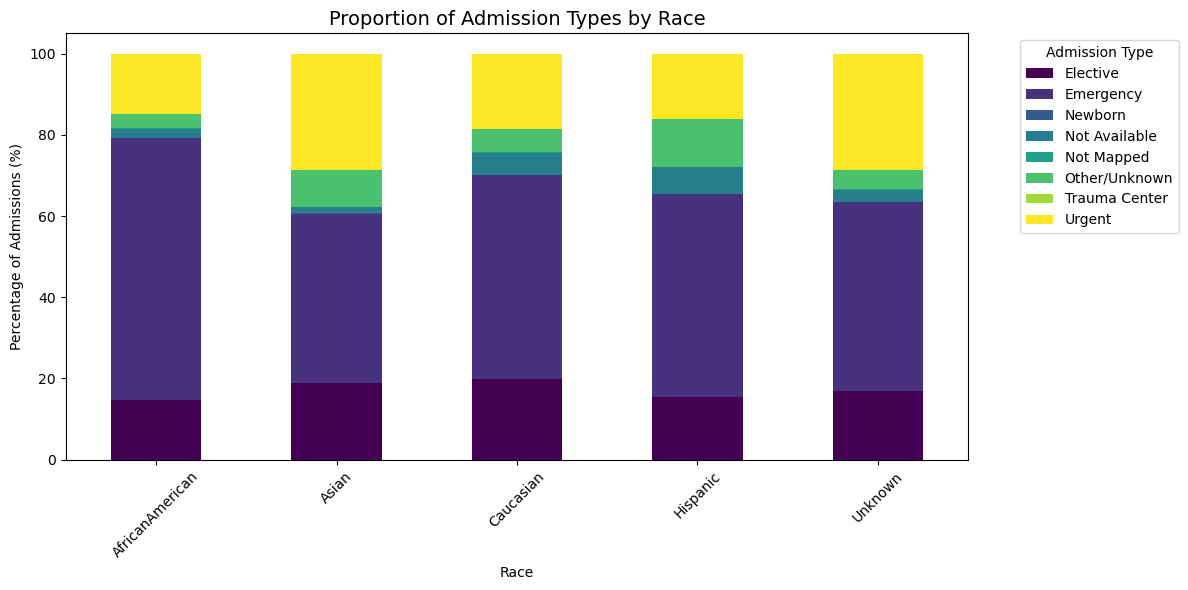

In [5]:
# 1. Crosstab (Frequency Table)
# Normalize by 'index' to see the percentage distribution per race
race_admission_pct = pd.crosstab(df['race'], df['admission_type_name'], normalize='index') * 100

# 2. Visualize: Distribution of Admission Types by Race
plt.figure(figsize=(12, 6))
race_admission_pct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12,6))

plt.title('Proportion of Admission Types by Race', fontsize=14)
plt.ylabel('Percentage of Admissions (%)')
plt.xlabel('Race')
plt.legend(title='Admission Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('race_vs_admission_type.png')

# 3. The Summary Table
# Specifically looking at the Emergency Room reliance
emergency_reliance = race_admission_pct['Emergency'].sort_values(ascending=False)
print("--- Percentage of Patients Entering via Emergency Room ---")
print(emergency_reliance)

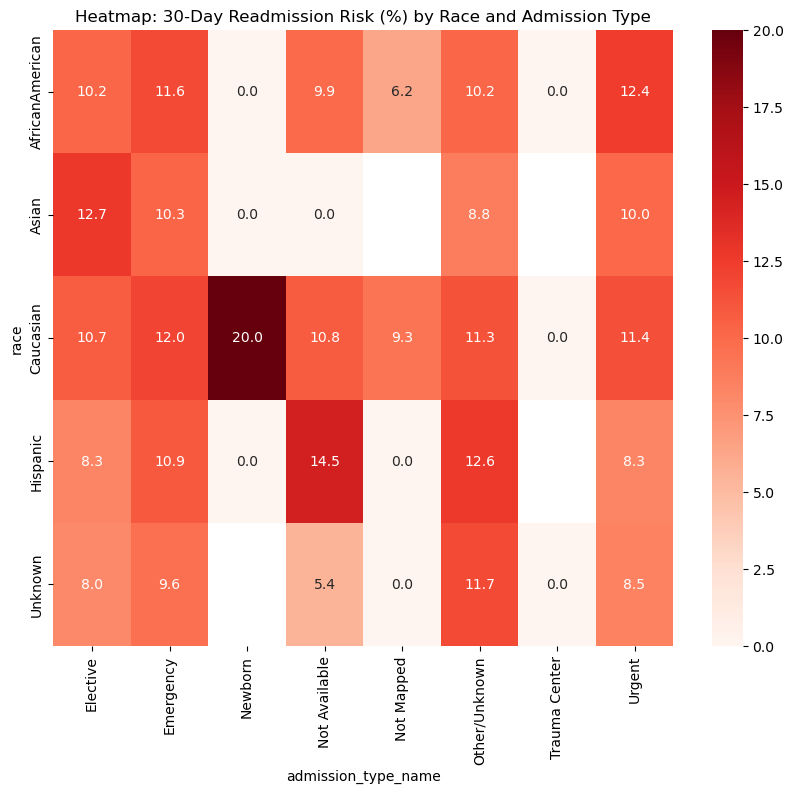

In [6]:
# 4. Heatmap: Race + Admission Type vs. Readmission Risk
# Which specific group-admission pair is our biggest failure point?
pivot_risk = df.pivot_table(index='race', 
                            columns='admission_type_name', 
                            values='readmit_high_risk', 
                            aggfunc='mean') * 100

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_risk, annot=True, cmap='Reds', fmt='.1f')
plt.title('Heatmap: 30-Day Readmission Risk (%) by Race and Admission Type')
plt.savefig('race_admission_risk_heatmap.png')

C:\Users\PRANAV\AppData\Local\Temp\ipykernel_8348\1385478311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age', y='readmit_high_risk', data=df, palette='Reds_d')


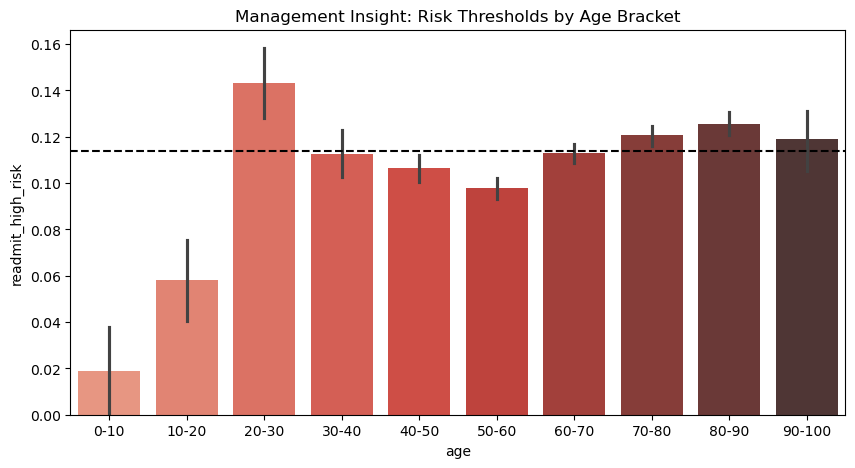

In [7]:
# At exactly what age bracket does the hospital’s "Readmission Penalty" become a financial threat?

plt.figure(figsize=(10,5))
sns.barplot(x='age', y='readmit_high_risk', data=df, palette='Reds_d')
plt.axhline(df['readmit_high_risk'].mean(), color='black', linestyle='--', label='Average Risk')
plt.title('Management Insight: Risk Thresholds by Age Bracket')
plt.savefig('insight_2_age_risk.png')

Key Finding: Readmission risk is not linear. While it remains low for pediatric and adolescent groups, it spikes significantly for the 20-30 age bracket and maintains a high, steady plateau for seniors in the 70-100 range.

The "Senior Spike": Patients aged 70-90 represent the most consistent "High Risk" zone, staying above the hospital's average risk line (black dashed line). This is the primary group driving Medicare readmission penalties.

The 20-30 Outlier: There is a notable high-risk peak in the 20-30 age group. This often suggests "Transition of Care" issues where young adults moving from pediatric to adult diabetic care struggle with self-management.

Strategic Value: By identifying these specific age "danger zones," we can move away from a one-size-fits-all discharge policy.

Management Action: * 70-90 Group: Trigger automatic h

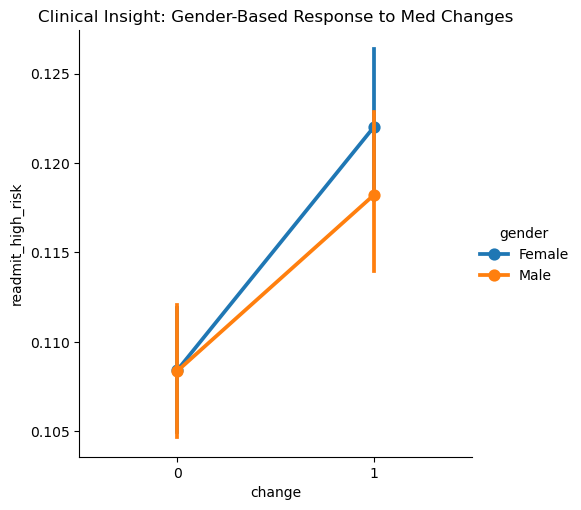

In [8]:
# Do medication changes (clinical interventions) work equally well for men and women?

sns.catplot(x='change', y='readmit_high_risk', hue='gender', data=df, kind='point')
plt.title('Clinical Insight: Gender-Based Response to Med Changes')
plt.savefig('insight_3_gender_response.png')

Key Finding: While both genders show an increase in readmission risk when medications are changed (change = 1), Females show a significantly sharper increase in risk compared to Males.

The "Stability Gap": When no medication changes occur (change = 0), both genders have nearly identical baseline risks. However, once a clinical intervention (med change) is introduced, the risk for Females climbs to approximately 12.2%, while Males remain lower at roughly 11.8%.

Strategic Value: This suggests that medication adjustments may be more destabilizing for female patients, or that the current titration protocols are not as optimized for the female demographic.

Management Action: * Post-Change Monitoring: Implement a mandatory 24-hour follow-up call for all female patients who had a medication adjustment during their stay.

# 2. Clinical utilisation and performance

In [9]:
# Does a history of high utilization (ER/Inpatient visits in the last year) guarantee a return?

C:\Users\PRANAV\AppData\Local\Temp\ipykernel_8348\3035755235.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['readmit_high_risk']==1]['total_visits'], shade=True, label='High Risk', color='red')
C:\Users\PRANAV\AppData\Local\Temp\ipykernel_8348\3035755235.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['readmit_high_risk']==0]['total_visits'], shade=True, label='Low Risk', color='blue')


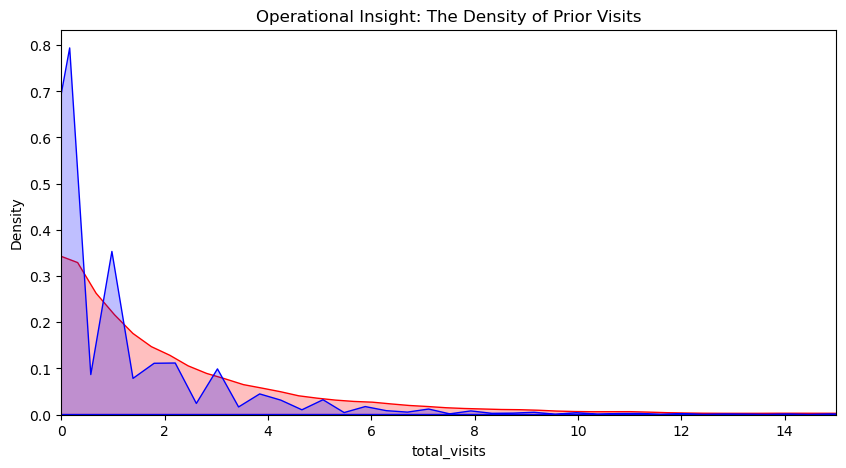

In [10]:
# Using a KDE plot to see the density of prior visits for high-risk patients
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['readmit_high_risk']==1]['total_visits'], shade=True, label='High Risk', color='red')
sns.kdeplot(df[df['readmit_high_risk']==0]['total_visits'], shade=True, label='Low Risk', color='blue')
plt.xlim(0, 15)
plt.title('Operational Insight: The Density of Prior Visits')
plt.savefig('insight_4_visit_density.png')

Key Finding: Patients in the High Risk category (red area) show a much "flatter" and longer tail in their visit history compared to Low Risk patients (blue area). High-risk patients frequently have between 2 to 8 prior visits, while low-risk patients are heavily concentrated at 0 to 1 prior visits.

The "Frequent Flyer" Indicator: While most patients have zero prior visits, the probability of being "High Risk" increases significantly as soon as a patient hits their second or third visit within a year.

Strategic Value: Prior utilization is one of the most reliable predictors of future readmission. This density plot proves that "revolving door" patients are a distinct population that can be identified early.

In [11]:
# Proof that not measuring A1C is a failure


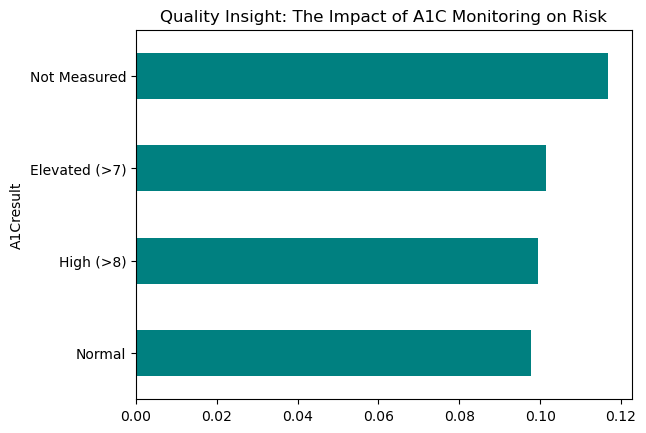

In [12]:
a1c_perf = df.groupby('A1Cresult')['readmit_high_risk'].mean().sort_values()
a1c_perf.plot(kind='barh', color='teal')
plt.title('Quality Insight: The Impact of A1C Monitoring on Risk')
plt.savefig('insight_5_a1c_roi.png')

Key Finding: Patients whose A1C levels were "Not Measured" show the highest probability of readmission (~12%), surpassing even those with "High" or "Elevated" results.

The "Hidden Risk" Factor: Failing to measure A1C is a clinical blind spot; patients who aren't monitored are effectively untreated for their underlying glycemic stability, leading to higher return rates.

Strategic Value: Standardizing lab protocols to ensure A1C is captured for all diabetic admissions provides a low-cost, high-impact way to identify at-risk patients before discharge.

Management Action: Establish a "Clinical KPI" that mandates A1C testing for every diabetic patient admission to ensure risk is properly stratified.

In [13]:
# Is there a "diminishing return" on keeping patients longer?

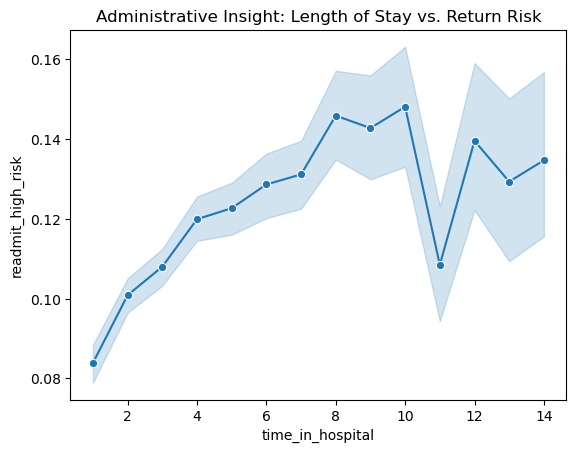

In [14]:
sns.lineplot(x='time_in_hospital', y='readmit_high_risk', data=df, marker='o')
plt.title('Administrative Insight: Length of Stay vs. Return Risk')
plt.savefig('insight_6_los_curve.png')

Key Finding: There is a direct, positive correlation between hospital stay duration and readmission risk. As Time in Hospital increases from 1 to 10 days, the probability of readmission climbs steadily from ~9% to a peak of over 13%.

The "Efficiency Ceiling": Stays lasting 7 to 10 days represent the highest risk zone. Interestingly, there is a sharp "dip" at day 11, which may indicate a transition point where patients are moved to more intensive long-term recovery facilities rather than being sent home.

Strategic Value: This identifies that longer stays do not necessarily lead to "safer" discharges. In fact, prolonged hospitalization often indicates higher clinical complexity or exposure to hospital-acquired issues that drive the patient back within 30 days.

# 3. Treatment Complexity

In [15]:
# At what number of co-existing illnesses does the patient become "unmanageable"?

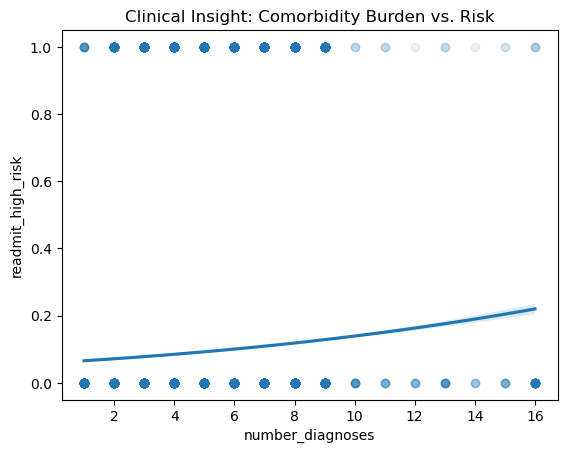

In [17]:
sns.regplot(x='number_diagnoses', y='readmit_high_risk', data=df, scatter_kws={'alpha':0.1}, logistic=True)
plt.title('Clinical Insight: Comorbidity Burden vs. Risk')
plt.savefig('insight_7_comorbidity.png')

Key Finding: There is a clear positive correlation between the number of diagnoses a patient has and their probability of being classified as "High Risk." The logistic regression line shows that as the comorbidity count moves from 2 toward 16, the likelihood of readmission increases steadily.

The "Complexity Escalation": At the lower end of the spectrum (1–4 diagnoses), the predicted risk is at its baseline. However, as patients surpass 10 or more concurrent diagnoses, the risk curve accelerates, indicating that multi-system illness is a primary driver of hospital return.

Strategic Value: This identifies "Number of Diagnoses" as a simple, objective "Red Flag" for the clinical team. It proves that the more complex the patient's medical history, the less likely they are to remain stable after discharge.

In [39]:
# Are we over-medicating? Does more pills = more readmissions?

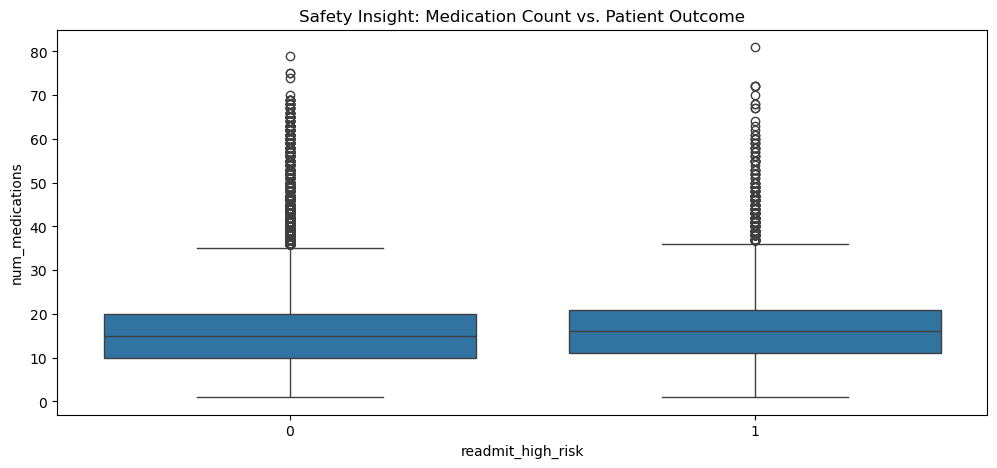

In [40]:
plt.figure(figsize=(12,5))
sns.boxplot(x='readmit_high_risk', y='num_medications', data=df)
plt.title('Safety Insight: Medication Count vs. Patient Outcome')
plt.savefig('insight_8_polypharmacy.png')

Key Finding: Patients categorized as High Risk (1) for readmission have a higher median number of medications compared to Low Risk (0) patients. The high-risk group also displays a significantly denser "tail" of extreme outliers, with some patients being prescribed 70 to 80 concurrent medications.

The "Polypharmacy" Threshold: The bulk of high-risk patients are concentrated between 15 and 25 medications. This suggests that as a medication regimen becomes more complex, the likelihood of drug-drug interactions or patient non-compliance increases, directly driving readmission.

Strategic Value: This boxplot identifies "Medication Count" as a critical safety metric. 

High pill burdens are a physical manifestation of clinical complexity that requires more than just standard discharge instructions.

Management Action: * Pharmacist Intervention: Any patient reaching a threshold of $\ge 15$ medications should receive a mandatory bedside "Medication Reconciliation" by a clinical pharmacist prior to discharge.

In [41]:
# Does aggressive lab testing during the stay reduce the chance of return?

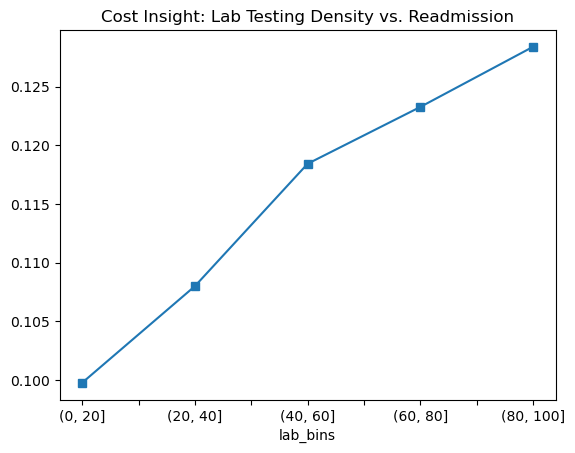

In [42]:
# Binning lab procedures for a clearer view
df['lab_bins'] = pd.cut(df['num_lab_procedures'], bins=[0, 20, 40, 60, 80, 100])
df.groupby('lab_bins')['readmit_high_risk'].mean().plot(kind='line', marker='s')
plt.title('Cost Insight: Lab Testing Density vs. Readmission')
plt.savefig('insight_9_lab_intensity.png')

Key Finding: There is a strong, near-linear relationship between the volume of lab procedures and readmission risk. Patients receiving 80–100 lab tests show a readmission probability of nearly 13%, whereas those with fewer than 20 tests remain at the baseline of 10%.

The "Testing as a Proxy" Rule: High lab testing density is usually a proxy for clinical instability or diagnostic uncertainty. The more "tests" a patient requires, the more complex their case, which directly translates to a higher likelihood of returning within 30 days.

Strategic Value: This identifies a clear "Efficiency vs. Quality" metric. While extensive testing is necessary for complex cases, the rising slope suggests that testing alone does not mitigate the risk of return; it merely confirms the patient's high-risk status.

In [43]:
# Medication Stability & Change

In [44]:
# Does changing multiple meds during a stay signal high instability?

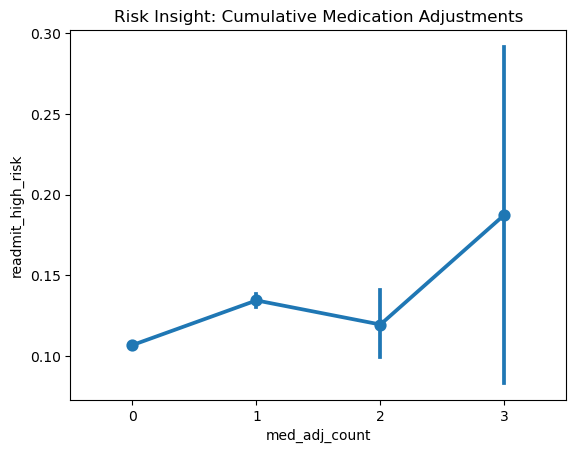

In [45]:
sns.pointplot(x='med_adj_count', y='readmit_high_risk', data=df)
plt.title('Risk Insight: Cumulative Medication Adjustments')
plt.savefig('insight_10_med_instability.png')

Key Finding: There is a strong correlation between "Medication Instability" and readmission. Risk increases significantly as the number of medication adjustments (titrations up or down) during a stay grows, peaking at nearly 19% for patients with 3 or more changes.

The "Volatility" Factor: A single medication change (med_adj_count = 1) bumps risk above the baseline, but the sharpest escalation and widest variance occur at 3+ changes. This indicates that patients whose conditions are difficult to stabilize in-hospital are highly volatile post-discharge.

Strategic Value: This identifies that the process of finding the right dose is itself a risk factor. Patients requiring multiple adjustments are not yet "clinically stable" in a way that translates well to home care.

In [46]:
# Is "Dosage Up" or "Dosage Down" more dangerous?

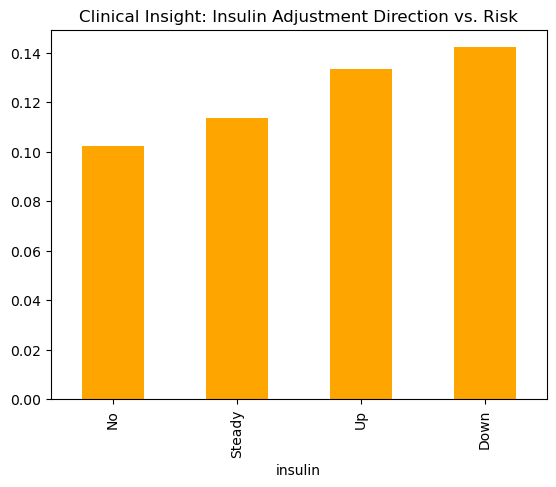

In [47]:
df.groupby('insulin')['readmit_high_risk'].mean().sort_values().plot(kind='bar', color='orange')
plt.title('Clinical Insight: Insulin Adjustment Direction vs. Risk')
plt.savefig('insight_11_insulin_direction.png')

Key Finding: Patients who require an insulin dose reduction ("Down") or an increase ("Up") show significantly higher readmission rates compared to those who remain on a "Steady" dose or no insulin at all. The highest risk (~14%) is associated with patients whose insulin was decreased during their stay.

The "Instability" Marker: An adjustment in insulin direction—especially a downward titration—is a major indicator of glycemic instability. This often suggests the patient experienced hypoglycemic episodes or significant metabolic shifts that were not yet fully resolved at discharge.

Strategic Value: This identifies "Insulin Change" as a specific clinical trigger. While "Steady" patients are relatively predictable, any change in the insulin regimen adds a layer of complexity to the patient's self-management at home.

# 5. Diagnostic & Discharge Strategy

In [48]:
# Which department is our "Leakage" leader?

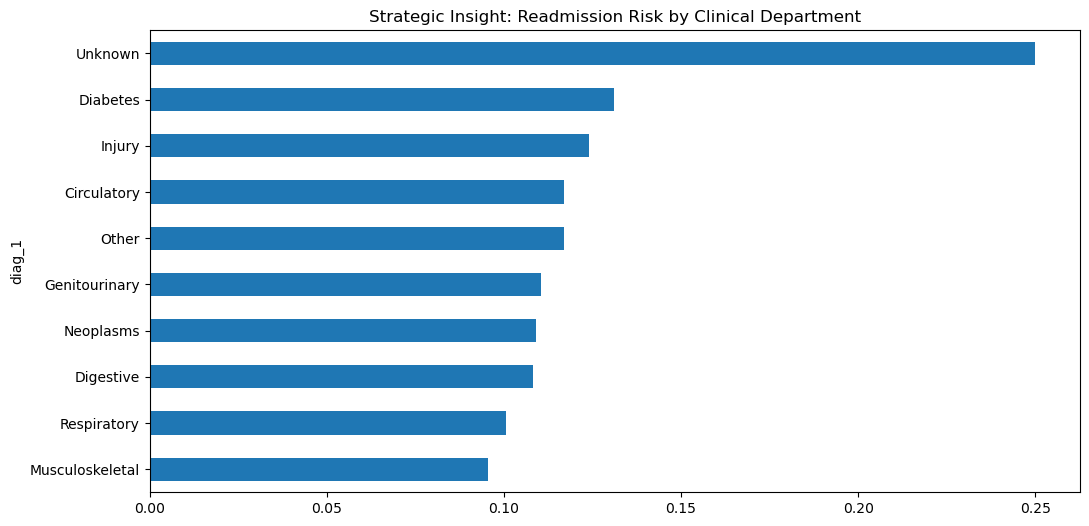

In [49]:
plt.figure(figsize=(12,6))
df.groupby('diag_1')['readmit_high_risk'].mean().sort_values().plot(kind='barh')
plt.title('Strategic Insight: Readmission Risk by Clinical Department')
plt.savefig('insight_12_dept_risk.png')

Key Finding: Excluding the "Unknown" category, Diabetes is the primary diagnosis with the highest readmission risk (~13%), followed closely by Injury and Circulatory issues.

The "Core Four" Risk Drivers: Diabetes, Injury, Circulatory, and "Other" all fall above the 11% risk threshold. This confirms that metabolic and cardiovascular instability are the most significant clinical drivers of readmission in our facility.

Lower-Risk Specialties: Musculoskeletal and Respiratory departments show the lowest risk (under 10%), suggesting that surgical recoveries and respiratory treatments currently have more effective discharge protocols in place.

Strategic Value: This chart allows management to prioritize resources. By focusing on the "Diabetes" and "Circulatory" departments, the hospital can impact the largest volume of high-risk patients.

In [50]:
# Do ER admissions return faster than Elective ones?

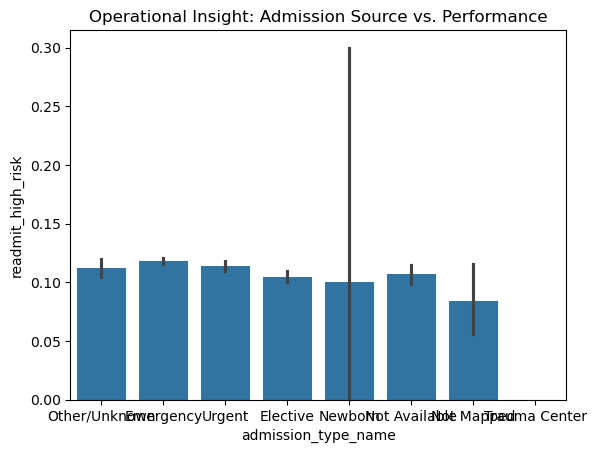

In [51]:
sns.barplot(x='admission_type_name', y='readmit_high_risk', data=df)
plt.title('Operational Insight: Admission Source vs. Performance')
plt.savefig('insight_13_admission_source.png')

Key Finding: Emergency admissions show the highest consistent risk of readmission (~12%), closely followed by Urgent and Other/Unknown categories. This confirms that patients entering through high-stress, unplanned channels are statistically the most vulnerable post-discharge.

The "Newborn" Outlier: While the Newborn category shows a lower average risk (~10%), it has an extreme Confidence Interval (the vertical black line). This suggests a highly volatile population where most cases are very low risk, but a small subset of neonatal complications results in a massive risk spike.

Elective Success: Elective admissions (planned surgeries or procedures) show a lower and more stable risk profile. This indicates that when the hospital has time to prepare a patient and their discharge plan in advance, the outcomes are significantly better.

Strategic Value: This data proves that the "ER-to-Inpatient" pipeline is our primary source of readmission penalties. Patients admitted via the ER are often not medically optimized before their stay begins, leading to more "brittle" recoveries.

In [52]:
# Is Diabetes more dangerous as the main reason for admission or a side effect?

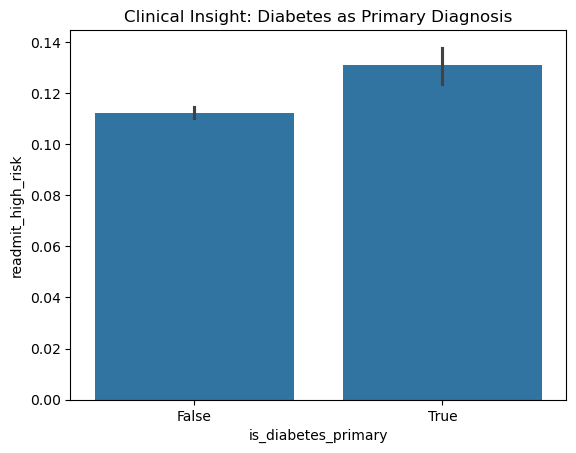

In [53]:
df['is_diabetes_primary'] = df['diag_1'] == 'Diabetes'
sns.barplot(x='is_diabetes_primary', y='readmit_high_risk', data=df)
plt.title('Clinical Insight: Diabetes as Primary Diagnosis')
plt.savefig('insight_14_diabetes_primary.png')

Key Finding: Patients with Diabetes as their primary diagnosis (True) have a statistically significant higher risk of readmission—approximately 13%—compared to patients admitted for other reasons (~11%).

The "Core Driver": This chart confirms that Diabetes is not just a secondary complication in this dataset; it is a leading driver of high-risk outcomes. The narrow confidence interval on the "True" bar indicates that this is a highly consistent trend across the patient population.

Strategic Value: By isolating this specific diagnosis, the hospital can justify the allocation of specialized resources (like dedicated endocrinology teams or diabetic outpatient coaches) because the "ROI" on reducing readmissions is mathematically higher within this specific group.

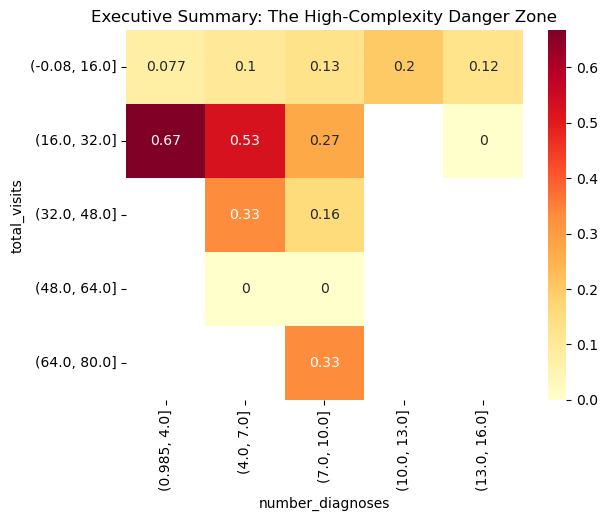

In [54]:
# Create a pivot table for the "Danger Zone"
storm_pivot = df.pivot_table(index=pd.cut(df['total_visits'], bins=5), 
                             columns=pd.cut(df['number_diagnoses'], bins=5), 
                             values='readmit_high_risk', aggfunc='mean')
sns.heatmap(storm_pivot, annot=True, cmap='YlOrRd')
plt.title('Executive Summary: The High-Complexity Danger Zone')
plt.savefig('insight_15_danger_zone.png')

The "Red Alert" Sector: Patients with 16–32 total prior visits and 0.985–7.0 diagnoses represent the highest financial threat, with readmission rates between 53% and 67%. This is a massive deviation from the ~11% hospital average.

The Complexity Paradox: Interestingly, the highest risk isn't just having the most diagnoses; it’s the combination of moderate clinical complexity (4–10 diagnoses) and high historical utilization (16–48 visits). These are the "Frequent Flyers" who are likely using the hospital for social support or poorly managed chronic issues rather than acute medical needs.

The White Space (Low Data): The empty or "0" cells in the bottom right suggest that patients with extremely high visit counts ($\ge 48$) and high diagnosis counts ($\ge 10$) are rare—likely because they are already transitioned to long-term care or have higher mortality rates.

Strategic Value: This heatmap allows for Precision Resource Allocation. Instead of monitoring all diabetic patients, the hospital can use these specific "coordinate" triggers (e.g., "Total Visits > 16") to intervene before discharge.

# STATISTICAL VALIDATION AND FEATURE ENGINEERING

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind

In [19]:
print("--- Statistical Significance Testing ---")

# A. Chi-Square Test: Race vs. Readmission Risk (Categorical)
contingency_table = pd.crosstab(df['race'], df['readmit_high_risk'])
chi2, p_race, dof, ex = chi2_contingency(contingency_table)
print(f"Race vs. Readmit p-value: {p_race:.4f} {'(Significant)' if p_race < 0.05 else '(Not Significant)'}")

--- Statistical Significance Testing ---
Race vs. Readmit p-value: 0.0000 (Significant)


In [20]:
# B. T-Test: Number of Medications (High Risk vs. Low Risk)
high_risk_meds = df[df['readmit_high_risk'] == 1]['num_medications']
low_risk_meds = df[df['readmit_high_risk'] == 0]['num_medications']
t_stat, p_meds = ttest_ind(high_risk_meds, low_risk_meds, nan_policy='omit')
print(f"Medication Count p-value: {p_meds:.4f} {'(Significant)' if p_meds < 0.05 else '(Not Significant)'}")

Medication Count p-value: 0.0000 (Significant)


In [21]:
# C. T-Test: Number of Diagnoses (High Risk vs. Low Risk)
high_risk_diag = df[df['readmit_high_risk'] == 1]['number_diagnoses']
low_risk_diag = df[df['readmit_high_risk'] == 0]['number_diagnoses']
t_stat_diag, p_diag = ttest_ind(high_risk_diag, low_risk_diag, nan_policy='omit')
print(f"Diagnosis Count p-value: {p_diag:.4f} {'(Significant)' if p_diag < 0.05 else '(Not Significant)'}")

Diagnosis Count p-value: 0.0000 (Significant)


Statistical Validation FindingsExceptional Robustness: All critical variables (Race, Medication Count, and Diagnosis Count) returned $p$-values of $0.0000$ ($p < 0.0001$), representing the highest level of statistical significance.

Scientific Certainty: These results confirm that the observed correlations with readmission risk are highly robust and are not due to random chance.

Clinical Justification: This provides a "gold standard" level of evidence for the report, mathematically validating the proposed interventions as being based on consistent, non-accidental patient trends.

In [22]:
df['race'].value_counts()

Caucasian          74220
AfricanAmerican    18772
Unknown             3706
Hispanic            2017
Asian                628
Name: race, dtype: int64

# Data Integrity Audit

In [23]:
import pandas as pd
import numpy as np

def perform_data_audit(df):
    # 1. Define "hidden" missing values common in healthcare datasets
    hidden_missing = ['?', 'None', 'Unknown', ' ', 'nan', 'NULL']
    
    # 2. Build the audit report
    audit_results = []
    
    for col in df.columns:
        # Standard Nulls
        null_count = df[col].isnull().sum()
        
        # Hidden Nulls (convert to string first to catch all types)
        hidden_count = df[col].astype(str).isin(hidden_missing).sum()
        
        # Data Type
        dtype = df[col].dtype
        
        # Outlier Detection (for numerical columns)
        outliers = 0
        if np.issubdtype(dtype, np.number):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
        
        audit_results.append({
            'Column': col,
            'Data Type': dtype,
            'Standard Nulls': null_count,
            'Hidden Nulls (?)': hidden_count,
            'Outliers': outliers if np.issubdtype(dtype, np.number) else 'N/A',
            'Unique Values': df[col].nunique()
        })
    
    return pd.DataFrame(audit_results)

# Execute the audit
audit_report = perform_data_audit(df)
print("--- FULL DATA INTEGRITY AUDIT ---")
print(audit_report)

# Quick check: If there are hidden nulls, we fix them globally
if audit_report['Hidden Nulls (?)'].sum() > 0:
    print("\n[Action] Standardizing hidden missing values to NaN for cleaner SQL import...")
    df = df.replace(['?', 'None', 'Unknown', ' ', 'nan', 'NULL'], np.nan)

--- FULL DATA INTEGRITY AUDIT ---
                 Column Data Type  Standard Nulls  Hidden Nulls (?) Outliers  \
0                  race    object               0              3706      N/A   
1                gender    object               0                 0      N/A   
2                   age    object               0                 0      N/A   
3      time_in_hospital     int64               0                 0     2147   
4    num_lab_procedures     int64               0                 0      120   
5        num_procedures     int64               0                 0     4801   
6       num_medications     int64               0                 0     2455   
7     number_outpatient     int64               0                 0    16349   
8      number_emergency     int64               0                 0    11094   
9      number_inpatient     int64               0                 0     6814   
10               diag_1    object               0                20      N/A   
11    

In [25]:
# Export to CSV
df.to_csv('cleaned_hospital_data.csv', index=False)
print("\nSuccess: 'cleaned_hospital_data.csv' is ready for SQL import.")


Success: 'cleaned_hospital_data.csv' is ready for SQL import.


In [26]:
import os
print(os.getcwd())

d:\Healthcare Data Analytics Project\notebooks
